<a href="https://colab.research.google.com/github/offjisung-alt/bottom_up_deeplearning/blob/main/4_%EC%8B%A0%EA%B2%BD%EB%A7%9D%ED%95%99%EC%8A%B5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone https://github.com/WegraLee/deep-learning-from-scratch.git

Cloning into 'deep-learning-from-scratch'...
remote: Enumerating objects: 1118, done.
remote: Counting objects: 100% (175/175), done.
remote: Compressing objects: 100% (45/45), done.
remote: Total 1118 (delta 141), reused 130 (delta 130), pack-reused 943 (from 2)
Receiving objects: 100% (1118/1118), 52.68 MiB | 28.17 MiB/s, done.
Resolving deltas: 100% (644/644), done.


In [2]:
import sys
sys.path.append('/content/deep-learning-from-scratch')

# 손실 함수 (Loss Function)

## 손실 함수란?

손실 함수(Loss Function)는 신경망의 예측값과 실제 정답 사이의 차이를 수치로 나타내는 함수이다.

즉, 현재 모델이 얼마나 잘못 예측하고 있는지를 측정하는 기준이다.

신경망의 학습 목표는 손실 함수의 값을 가능한 작게 만드는 것이다.

예를 들어 정답이

$$
[0, 1, 0]
$$

이고,

신경망의 출력이

$$
[0.1, 0.8, 0.1]
$$

이라면 손실은 작다.

반면

$$
[0.8, 0.1, 0.1]
$$

이라면 손실은 커진다.

---

## 손실 함수를 사용하는 이유

신경망은 학습 과정에서 가중치와 편향을 수정해야 한다.

하지만 단순히 정답을 맞았는지 틀렸는지 만으로는 얼마나 수정해야 하는지 알 수 없다.

예를 들어

예측값 A

$$
[0.49, 0.51]
$$

예측값 B

$$
[0.01, 0.99]
$$

는 둘 다 같은 정답을 맞힌 결과일 수 있다.

정확도는 둘 다 100%이지만,

예측값 B가 훨씬 더 좋은 예측이다.

손실 함수는 이러한 차이를 수치로 표현하여 신경망이 학습할 수 있도록 도와준다.

---

# 오차제곱합 (Sum of Squares Error, SSE)

오차제곱합은 예측값과 정답의 차이를 제곱하여 모두 더한 값이다.

수식은 다음과 같다.

$$
E = \frac{1}{2}\sum_{k}(y_k-t_k)^2
$$

여기서

- $y_k$ : 신경망의 출력값
- $t_k$ : 정답 레이블
- $E$ : 손실값

이다.

---

## 오차제곱합 예시

정답

$$
t = [0, 1, 0]
$$

예측

$$
y = [0.1, 0.8, 0.1]
$$

이라면

$$
E=
\frac{1}{2}
\left(
(0.1-0)^2
+
(0.8-1)^2
+
(0.1-0)^2
\right)
$$

$$
=
\frac{1}{2}(0.01+0.04+0.01)
$$

$$
=
0.03
$$

이 된다.

---

## 오차제곱합의 특징

### 장점

- 계산이 간단하다.
- 회귀 문제에서 많이 사용된다.

### 단점

- 분류 문제에서는 성능이 좋지 않다.
- 확률 분포를 잘 반영하지 못한다.

---

# 교차 엔트로피 오차 (Cross Entropy Error)

교차 엔트로피 오차는 분류 문제에서 가장 많이 사용하는 손실 함수이다.

수식은 다음과 같다.

$$
E = -\sum_{k} t_k \log y_k
$$

여기서

- $t_k$ : 정답 레이블
- $y_k$ : 예측 확률

이다.

---

## 원-핫 인코딩인 경우

정답이

$$
t=[0,1,0]
$$

이라면

정답 위치만 계산에 사용된다.

즉

$$
E = -\log(0.8)
$$

이 된다.

---

## 교차 엔트로피 오차의 특징

### 1. 정답 확률이 높을수록 손실이 작다.

예를 들어

정답 클래스의 확률이

$$
0.9
$$

라면

$$
-\log(0.9)
=
0.105
$$

이다.

반면

$$
0.1
$$

이라면

$$
-\log(0.1)
=
2.302
$$

가 된다.

즉, 정답을 틀리게 예측할수록 큰 손실을 부여한다.

---

### 2. 분류 문제에 적합하다.

Softmax 함수의 출력은 확률 분포이므로

교차 엔트로피 오차와 함께 사용하는 것이 가장 자연스럽다.

---

### 3. 현재 딥러닝에서 가장 많이 사용된다.

대부분의 이미지 분류, 자연어 처리 모델은

Softmax + Cross Entropy

조합을 사용한다.

---

# 손실 함수를 사용하는 이유

신경망은 가중치와 편향을 수정하면서 학습한다.

이때 얼마나 수정해야 하는지 알려주는 기준이 필요하다.

정확도(Accuracy)는

- 맞으면 1
- 틀리면 0

만 알려주기 때문에 미분이 불가능하다.

따라서 경사하강법(Gradient Descent)을 사용할 수 없다.

반면 손실 함수는 연속적인 값을 가지므로 미분이 가능하다.

즉,

$$
\text{가중치}
\rightarrow
\text{예측}
\rightarrow
\text{손실 함수}
\rightarrow
\text{미분}
\rightarrow
\text{가중치 업데이트}
$$

과정을 통해 신경망이 학습할 수 있게 된다.

---

# 정리

- 손실 함수는 예측값과 정답 사이의 차이를 수치로 나타낸다.
- 신경망은 손실 함수를 최소화하는 방향으로 학습한다.
- 오차제곱합(SSE)은 회귀 문제에서 주로 사용된다.

$$
E = \frac{1}{2}\sum_{k}(y_k-t_k)^2
$$

- 교차 엔트로피 오차(CEE)는 분류 문제에서 주로 사용된다.

$$
E = -\sum_{k} t_k \log y_k
$$

- 정확도는 미분이 불가능하지만 손실 함수는 미분 가능하므로 학습에 사용할 수 있다.
- 딥러닝에서는 일반적으로 Softmax 함수와 교차 엔트로피 오차를 함께 사용한다.

In [3]:
import numpy as np

def mean_squared_error(y, t):
    return 0.5 * np.sum((y-t)**2)

def cross_entropy_error(y, t):
    delta = 1e-7  # 0일때 -무한대가 되지 않기 위해 작은 값을 더함
    return -np.sum(t * np.log(y + delta))

# 수치미분, 편미분, 기울기, 경사하강법

## 미분이란?

미분(Differentiation)은 함수의 특정 지점에서 변화율을 구하는 것이다.

즉, 입력값이 아주 조금 변했을 때 출력값이 얼마나 변하는지를 나타낸다.

함수

$$
f(x)
$$

의 미분은 다음과 같이 정의된다.

$$
\frac{df(x)}{dx}
=
\lim_{h\to0}
\frac{f(x+h)-f(x)}{h}
$$

미분값이 크면 함수가 급격하게 변하고 있다는 의미이고,

미분값이 작으면 함수가 완만하게 변하고 있다는 의미이다.

---

# 수치미분 (Numerical Differentiation)

수치미분은 미분 공식을 직접 사용하지 않고 컴퓨터가 근사적으로 미분값을 계산하는 방법이다.

가장 단순한 방법은 다음과 같다.

$$
\frac{f(x+h)-f(x)}{h}
$$

하지만 이 방법은 오차가 비교적 크다.

따라서 딥러닝에서는 중심 차분(Central Difference)을 사용한다.

$$
\frac{f(x+h)-f(x-h)}{2h}
$$

여기서

$$
h = 10^{-4}
$$

정도의 작은 값을 사용한다.

---

## 수치미분의 특징

### 장점

- 구현이 쉽다.
- 미분 공식을 몰라도 된다.

### 단점

- 계산량이 매우 크다.
- 오차가 발생한다.
- 실제 딥러닝 학습에는 사용하지 않는다.

주로 역전파 구현이 올바른지 확인하는 Gradient Check 용도로 사용한다.

---

# 편미분 (Partial Derivative)

변수가 여러 개인 함수에서 특정 변수 하나만 변화시킬 때의 미분을 편미분이라고 한다.

예를 들어

$$
f(x,y)=x^2+y^2
$$

가 있다고 하자.

---

## x에 대한 편미분

y를 상수로 취급한다.

$$
\frac{\partial f}{\partial x}
=
2x
$$

---

## y에 대한 편미분

x를 상수로 취급한다.

$$
\frac{\partial f}{\partial y}
=
2y
$$

---

## 편미분의 의미

편미분은

"한 변수만 움직였을 때 함수가 얼마나 변하는가"

를 의미한다.

딥러닝에서는 가중치가 수천~수억 개 존재하므로 편미분이 매우 중요하다.

---

# 기울기 (Gradient)

기울기는 모든 편미분 값을 하나로 모은 벡터이다.

함수

$$
f(x,y)=x^2+y^2
$$

에 대해

$$
\frac{\partial f}{\partial x}=2x
$$

$$
\frac{\partial f}{\partial y}=2y
$$

이므로

기울기는

$$
\nabla f
=
\left(
\frac{\partial f}{\partial x},
\frac{\partial f}{\partial y}
\right)
$$

이다.

즉,

$$
\nabla f=(2x,2y)
$$

가 된다.

---

## 기울기의 의미

기울기는 함수가 가장 빠르게 증가하는 방향을 나타낸다.

예를 들어

$$
f(x,y)=x^2+y^2
$$

에서

$$
(3,4)
$$

의 기울기는

$$
(6,8)
$$

이다.

즉,

$$
(6,8)
$$

방향으로 이동하면 함수값이 가장 빠르게 증가한다.

반대로

$$
(-6,-8)
$$

방향으로 이동하면 함수값이 가장 빠르게 감소한다.

---

# 경사하강법 (Gradient Descent)

딥러닝의 목표는 손실 함수(Loss Function)를 최소화하는 것이다.

기울기는 함수가 가장 빠르게 증가하는 방향을 알려준다.

따라서 손실 함수를 줄이기 위해서는 기울기의 반대 방향으로 이동하면 된다.

이를 경사하강법이라고 한다.

---

## 경사하강법의 수식

현재 위치를

$$
x
$$

라고 할 때

다음 위치는

$$
x = x - \eta \frac{df}{dx}
$$

로 갱신한다.

여기서

- $\eta$ : 학습률(Learning Rate)
- $\frac{df}{dx}$ : 미분값

이다.

---

## 다변수 함수의 경우

$$
x_0=x_0-\eta\frac{\partial f}{\partial x_0}
$$

$$
x_1=x_1-\eta\frac{\partial f}{\partial x_1}
$$

$$
x_2=x_2-\eta\frac{\partial f}{\partial x_2}
$$

와 같이 모든 변수에 대해 동시에 업데이트한다.

---

## 학습률 (Learning Rate)

학습률은 한 번에 얼마나 이동할지를 결정한다.

### 학습률이 너무 작은 경우

$$
\eta = 0.0001
$$

- 이동 속도가 매우 느림
- 학습 시간이 오래 걸림

### 학습률이 너무 큰 경우

$$
\eta = 10
$$

- 최솟값을 지나쳐 버림
- 발산할 수 있음

따라서 적절한 학습률을 선택해야 한다.

---

# 신경망 학습 과정

신경망 학습은 다음 과정을 반복한다.

1. 입력 데이터를 넣는다.
2. 예측값을 계산한다.
3. 손실 함수를 계산한다.
4. 기울기를 계산한다.
5. 경사하강법으로 가중치를 수정한다.
6. 손실 함수가 작아질 때까지 반복한다.

즉,

$$
\text{입력}
\rightarrow
\text{예측}
\rightarrow
\text{손실 함수}
\rightarrow
\text{기울기 계산}
\rightarrow
\text{경사하강법}
\rightarrow
\text{가중치 업데이트}
$$

과정을 반복하면서 학습이 진행된다.

---

# 정리

## 수치미분

$$
\frac{f(x+h)-f(x-h)}{2h}
$$

- 컴퓨터가 근사적으로 미분값 계산
- Gradient Check에 사용

## 편미분

$$
\frac{\partial f}{\partial x}
$$

- 여러 변수 중 하나만 미분

## 기울기

$$
\nabla f
=
\left(
\frac{\partial f}{\partial x_1},
\frac{\partial f}{\partial x_2},
\cdots
\right)
$$

- 함수가 가장 빠르게 증가하는 방향

## 경사하강법

$$
x=x-\eta\nabla f
$$

- 기울기의 반대 방향으로 이동
- 손실 함수를 최소화하는 알고리즘
- 딥러닝 학습의 핵심 원리

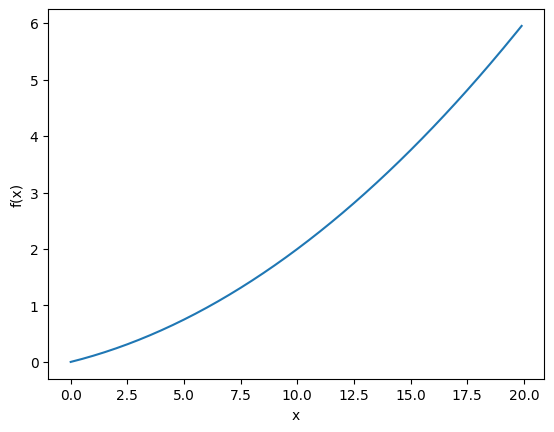

0.200000000000089
0.29999999999996696


In [4]:
import numpy as np
import matplotlib.pylab as plt


def numerical_diff(f, x):
    h = 10e-4
    return (f(x + h) - f(x - h)) / (2 * h)

def function_1(x):
    return 0.01*x**2 + 0.1*x


x = np.arange(0.0, 20.0, 0.1)
y = function_1(x)
plt.xlabel("x")
plt.ylabel("f(x)")
plt.plot(x, y)
plt.show()

print(numerical_diff(function_1, 5))
print(numerical_diff(function_1, 10))


In [5]:
def tangent_line(f, x):
        d = numerical_diff(f, x)
        print(d)
        y = f(x) - d*x
        return lambda t: d*t + y


tf = tangent_line(function_1, 5)
y2 = tf(x)
#plt.plot(x, y2)
#plt.show()


# 편미분
# f(x0, x1) = x0² + x1²
def function_2(x):
    return x[0]**2 + x[1]**2


def function_tmp1(x0):
    return x0**2 + 4.0**2.0



def function_tmp2(x1):
    return 3.0**2.0 + x1 * x1


print(numerical_diff(function_tmp1, 3.0))
print(numerical_diff(function_tmp2, 4.0))

0.200000000000089
5.999999999998451
8.000000000000895


[6. 8.]
[0. 4.]
[6. 0.]
[-6.11110793e-10  8.14814391e-10]
[-2.58983747e+13 -1.29524862e+12]
[-2.99999994  3.99999992]


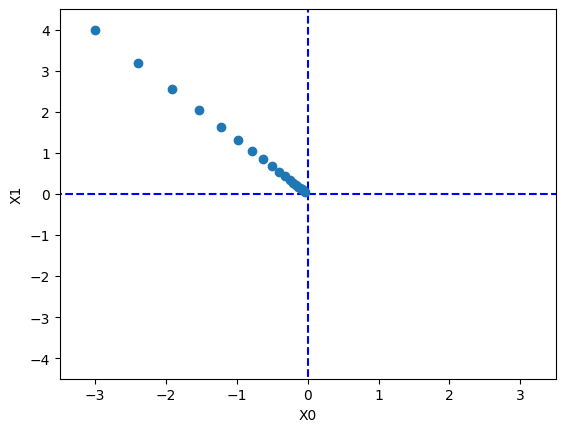

In [6]:
import numpy as np
import matplotlib.pylab as plt


def numerical_gradient(f, x):
    h = 1e-4
    grad = np.zeros_like(x)  # x와 형상이 같은 배열을 생성

    for idx in range(x.size):
        tmp_val = x[idx]
        # f(x+h) 계산
        x[idx] = tmp_val + h
        fxh1 = f(x)

        # f(x-h) 계산
        x[idx] = tmp_val - h
        fxh2 = f(x)

        grad[idx] = (fxh1 - fxh2) / (2 * h)
        x[idx] = tmp_val  # 값 복원

    return grad


# f(x0, x1) = x0² + x1²
def function_2(x):
    return x[0]**2 + x[1]**2


print(numerical_gradient(function_2, np.array([3.0, 4.0])))  # [ 6.  8.]
print(numerical_gradient(function_2, np.array([0.0, 2.0])))  # [ 0.  4.]
print(numerical_gradient(function_2, np.array([3.0, 0.0])))  # [ 6.  0.]

# 경사 하강법

# f:최적화하려는 함수
# init_x : 초깃값
# lr : 학습률
# step_num : 반복횟수
def gradient_descent(f, init_x, lr=0.01, step_num=100):
    x = init_x
    x_history = []

    for i in range(step_num):
        x_history.append(x.copy())
        grad = numerical_gradient(f, x)
        x -= lr * grad

    return x, np.array(x_history)


# 경사법으로 f(x0, x1) = x0² + x1²의 최솟값을 구해라
init_x = np.array([-3.0, 4.0])
x, x_history = gradient_descent(function_2, init_x, lr=0.1)
print(x)

# 학습률이 너무 큼
init_x = np.array([-3.0, 4.0])
x, x_history = gradient_descent(function_2, init_x, lr=10.0)
print(x)

# 학습률이 너무 작음
init_x = np.array([-3.0, 4.0])
x, x_history = gradient_descent(function_2, init_x, lr=1e-10)
print(x)

# 그래프
init_x = np.array([-3.0, 4.0])
x, x_history = gradient_descent(function_2, init_x, lr=0.1, step_num=20)

plt.plot([-5, 5], [0, 0], '--b')
plt.plot([0, 0], [-5, 5], '--b')
plt.plot(x_history[:, 0], x_history[:, 1], 'o')

plt.xlim(-3.5, 3.5)
plt.ylim(-4.5, 4.5)
plt.xlabel("X0")
plt.ylabel("X1")
plt.show()

# 신경망에서의 기울기와 학습 알고리즘

## 신경망에서의 기울기(Gradient)

신경망의 목표는 손실 함수(Loss Function)의 값을 최소화하는 가중치(Weight)와 편향(Bias)을 찾는 것이다.

예를 들어 손실 함수를

$$
L(W)
$$

라고 하면, 가중치 (W)를 조금 변경했을 때 손실 함수가 얼마나 변하는지를 알아야 한다.

이때 사용하는 것이 기울기(Gradient)이다.

기울기는 손실 함수를 각 가중치에 대해 편미분한 값들의 집합이다.

예를 들어 가중치가 두 개라면

$$
W = (w_1, w_2)
$$

손실 함수의 기울기는

$$
\nabla L
=
\left(
\frac{\partial L}{\partial w_1},
\frac{\partial L}{\partial w_2}
\right)
$$

가 된다.

---

## 기울기의 의미

기울기는 손실 함수가 가장 빠르게 증가하는 방향을 나타낸다.

예를 들어

$$
\nabla L = (3, 5)
$$

라면

- (w_1) 방향으로는 3만큼 증가
- (w_2) 방향으로는 5만큼 증가

하는 방향이라는 의미이다.

하지만 우리의 목표는 손실 함수를 최소화하는 것이므로

기울기의 반대 방향으로 이동해야 한다.

즉,

$$
-\nabla L
$$

방향으로 이동한다.

---

## 신경망에서 기울기를 구하는 이유

신경망에는 수많은 가중치가 존재한다.

예를 들어

- 입력층 → 은닉층 가중치
- 은닉층 → 출력층 가중치
- 각 층의 편향

모두 학습 대상이다.

기울기를 계산하면

"어떤 가중치를 얼마나 수정해야 손실 함수가 감소하는가"

를 알 수 있다.

즉, 기울기는 가중치 업데이트 방향을 알려주는 나침반 역할을 한다.

---

# 신경망 학습 알고리즘

신경망의 학습은 다음 순서로 진행된다.

---

## 1단계 : 미니배치(Mini-Batch)

전체 데이터 중 일부를 무작위로 선택한다.

예를 들어

- 전체 데이터 : 60,000개
- 미니배치 : 100개

라면 100개의 데이터만 사용하여 학습을 진행한다.

이렇게 하면 계산량을 줄일 수 있다.

---

## 2단계 : 기울기 계산

선택된 미니배치 데이터를 이용하여 손실 함수를 계산한다.

그 후 가중치와 편향에 대한 기울기를 구한다.

예를 들어

$$
\frac{\partial L}{\partial W_1}
$$

$$
\frac{\partial L}{\partial b_1}
$$

$$
\frac{\partial L}{\partial W_2}
$$

$$
\frac{\partial L}{\partial b_2}
$$

등을 계산한다.

기울기는 손실 함수를 줄이기 위한 방향을 나타낸다.

---

## 3단계 : 매개변수 갱신

구한 기울기를 이용하여 가중치와 편향을 수정한다.

경사하강법을 사용하면

$$
W = W - \eta \frac{\partial L}{\partial W}
$$

$$
b = b - \eta \frac{\partial L}{\partial b}
$$

로 갱신한다.

여기서

- (W) : 가중치
- (b) : 편향
- (\eta) : 학습률(Learning Rate)

이다.

---

## 4단계 : 반복

1~3단계를 반복하면서 손실 함수의 값을 점점 줄여 나간다.

손실 함수가 충분히 작아질 때까지 반복 학습한다.

---

# 신경망 학습의 전체 흐름

신경망 학습은 다음 과정으로 이루어진다.

$$
\text{입력 데이터}
\rightarrow
\text{순전파}
\rightarrow
\text{예측값}
\rightarrow
\text{손실 함수}
\rightarrow
\text{기울기 계산}
\rightarrow
\text{가중치 업데이트}
\rightarrow
\text{반복}
$$

---

## 순전파(Forward Propagation)

입력 데이터를 신경망에 넣어 예측값을 계산하는 과정이다.

예를 들어

$$
X
\rightarrow
Affine
\rightarrow
ReLU
\rightarrow
Affine
\rightarrow
Softmax
$$

를 수행하여 예측값을 얻는다.

---

## 손실 함수 계산

예측값과 정답을 비교한다.

예를 들어

- 예측값 : 0.8
- 정답 : 1

이라면 손실 함수가 계산된다.

대표적으로

- 오차제곱합(SSE)
- 교차 엔트로피 오차(CEE)

를 사용한다.

---

## 기울기 계산

손실 함수가 각 가중치에 대해 얼마나 변하는지 계산한다.

즉,

$$
\frac{\partial L}{\partial W}
$$

를 계산하는 과정이다.

실제 딥러닝에서는 수치미분 대신 역전파(Backpropagation)를 사용한다.

---

## 가중치 업데이트

기울기를 이용하여 손실 함수가 감소하는 방향으로 이동한다.

$$
W = W - \eta \frac{\partial L}{\partial W}
$$

이 과정을 반복하면 손실 함수가 점점 감소한다.

---

# 학습 알고리즘 구현 흐름

파이썬 코드 수준에서 보면 다음과 같은 순서로 구현된다.

python for i in range(iterations):      # 1. 미니배치 추출     x_batch, t_batch      # 2. 기울기 계산     grad = network.gradient(x_batch, t_batch)      # 3. 매개변수 갱신     for key in network.params:         network.params[key] -= learning_rate * grad[key]      # 4. 손실 함수 계산     loss = network.loss(x_batch, t_batch)

---

# 정리

## 기울기

$$
\nabla L
=
\left(
\frac{\partial L}{\partial w_1},
\frac{\partial L}{\partial w_2},
\cdots
\right)
$$

- 손실 함수가 가장 빠르게 증가하는 방향
- 가중치 수정 방향을 알려줌

---

## 경사하강법

$$
W = W - \eta \frac{\partial L}{\partial W}
$$

- 기울기의 반대 방향으로 이동
- 손실 함수 최소화

---

## 신경망 학습 과정

1. 미니배치 추출
2. 순전파 수행
3. 손실 함수 계산
4. 기울기 계산
5. 가중치 업데이트
6. 반복

즉,

$$
\text{입력}
\rightarrow
\text{예측}
\rightarrow
\text{손실}
\rightarrow
\text{기울기}
\rightarrow
\text{가중치 수정}
\rightarrow
\text{반복}
$$

을 통해 신경망은 점점 더 좋은 예측을 하도록 학습된다.

In [7]:
'''
전제
신경망에는 적응 가능한 가중치와 편향이 있고, 이 가중치와 편향을 훈련 데이터에 적응하도록 조정하는 과정을 '학습'이라 한다.
신경망 학습은 다음과 같이 4단계로 수행한다.

1단계 - 미니배치
훈련 데이터 중 일부를 무작위로 가져온다. 이렇게 선별한 데이터를 미니배치라 하며,
그 미니배치의 손실함수 값을 줄이는 것이 목표이다.

2단계 - 기울기 산출
미니배치의 손실 함수 값을 줄이기 위해 각 가중치 매개변수의 기울기를 구한다.
기울기는 손실 함수의 값을 가장 작게 하는 방향을 제시한다.

3단계 - 매개변수 갱신
가중치 매개변수를 기울기 방향으로 아주 조금 갱신한다.

4단계 - 반복
1~3단계를 반복한다.

데이터를 무작위로 선정하기 때문에 확률적 경사 하강법stochastic gradient descent,
SGD라고 부른다.
'''
import sys
import os
import numpy as np
sys.path.append(os.pardir)
from common.functions import sigmoid, softmax, cross_entropy_error
from common.gradient import numerical_gradient


class TwoLayerNet:
    """
    params : 신경망의 매개변수를 보관하는 딕셔너리 변수.
    params['W1']은 1번째 층의 가중치, params['b1']은 1번째 층의 편향.
    params['W2']은 2번째 층의 가중치, params['b2']은 2번째 층의 편향.

    grad : 기울기를 보관하는 딕셔너리 변수(numerical_gradient()의 반환값)
    grads['W1']은 1번째 층의 가중치의 기울기, grads['b1']은 1번째 층의 편향의 기울기.
    grads['W2']은 2번째 층의 가중치의 기울기, grads['b2']은 2번째 층의 편향의 기울기.
    """
    # 초기화를 수행한다.
    def __init__(self, input_size, hidden_size, output_size,
                 weight_init_std=0.01):
        # 가중치 초기화
        self.params = {}
        self.params['W1'] = weight_init_std * \
            np.random.randn(input_size, hidden_size)
        self.params['b1'] = np.zeros(hidden_size)
        self.params['W2'] = weight_init_std * \
            np.random.randn(hidden_size, output_size)
        self.params['b2'] = np.zeros(output_size)

    # 예측(추론)을 수행한다.
    def predict(self, x):
        W1, W2 = self.params['W1'], self.params['W2']
        b1, b2 = self.params['b1'], self.params['b2']

        a1 = np.dot(x, W1) + b1
        z1 = sigmoid(a1)
        a2 = np.dot(z1, W2) + b2
        y = softmax(a2)

        return y

    # 손실 함수의 값을 구한다.
    # x : 입력데이터, t : 정답 레이블
    def loss(self, x, t):
        y = self.predict(x)

        return cross_entropy_error(y, t)

    # 정확도를 구한다.
    def accuracy(self, x, t):
        y = self.predict(x)
        y = np.argmax(y, axis=1)
        t = np.argmax(t, axis=1)

        accuracy = np.sum(y == t) / float(x.shape[0])
        return accuracy

    # 가중치 매개변수의 기울기를 구한다.
    def numerical_gradient(self, x, t):
        loss_W = lambda W: self.loss(x, t)

        grads = {}
        grads['W1'] = numerical_gradient(loss_W, self.params['W1'])
        grads['b1'] = numerical_gradient(loss_W, self.params['b1'])
        grads['W2'] = numerical_gradient(loss_W, self.params['W2'])
        grads['b2'] = numerical_gradient(loss_W, self.params['b2'])

        return grads


if __name__ == '__main__':
    net = TwoLayerNet(input_size=784, hidden_size=100, output_size=10)
    print(net.params['W1'].shape)  # (784, 100)
    print(net.params['b1'].shape)  # (100,)
    print(net.params['W2'].shape)  # (100, 10)
    print(net.params['b2'].shape)  # (10,)

    x = np.random.rand(100, 784)  # 더미 입력 데이터(100장 분량)
    t = np.random.rand(100, 10)   # 더미 정답 레이블(100장 분량)

    grads = net.numerical_gradient(x, t)  # 기울기 계산

    print(grads['W1'].shape)  # (784, 100)
    print(grads['b1'].shape)  # (100,)
    print(grads['W2'].shape)  # (100, 10)
    print(grads['b2'].shape)  # (10,)

(784, 100)
(100,)
(100, 10)
(10,)
(784, 100)
(100,)
(100, 10)
(10,)


In [10]:
import numpy as np
import sys
import os
from dataset.mnist import load_mnist
sys.path.append(os.pardir)


"""
60000개의 훈련 데이터에서 임의로 100개의 데이터(이미지&정답 레이블)을 추려냄.
100개의 미니배치를 대상으로 확률적 경사 하강법을 수행해 매개변수를 갱신한다.
경사법에 의한 갱신 횟수를 1000번으로 설정하고 갱신할 때마다 손실 함수를 계산한다.
"""
(x_train, t_train), (x_test, t_test) = \
    load_mnist(normalize=True, one_hot_label=True)

# 하이퍼 파라메터
iters_num = 1000  # 반복횟수
train_size = x_train.shape[0]
batch_size = 100  # 미니배치 크기
learning_rate = 0.1
network = TwoLayerNet(input_size=784, hidden_size=50, output_size=10)

train_loss_list = []
train_acc_list = []
test_acc_list = []


iter_per_epoch = max(train_size // batch_size, 1)

for i in range(iters_num):
    print(i)

    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]

    grad = network.numerical_gradient(x_batch, t_batch)

    for key in ('W1', 'b1', 'W2', 'b2'):
        network.params[key] -= learning_rate * grad[key]

    loss = network.loss(x_batch, t_batch)
    train_loss_list.append(loss)

    if i % iter_per_epoch == 0:
        train_acc = network.accuracy(x_train, t_train)
        test_acc = network.accuracy(x_test, t_test)
        train_acc_list.append(train_acc)
        test_acc_list.append(test_acc)

        print("train acc, test acc | "
              + str(train_acc) + ", " + str(test_acc))


"""
위의 계산에서 손실 함수의 값이 점점 감소하게 되는데, 이때의 손실 함수는
훈련 데이터의 미니배치에 대한 손실 함수를 말한다.
훈련 데이터 외의 데이터를 올바르게 인식하는지(오버피팅이 일어나지 않았는지) 확인 필요.
1 에폭별로 훈련 데이터와 시험 데이터에 대한 정확도를 기록하도록 수정.
에폭epoch : 학습에서 훈련 데이터를 모두 소진했을 때의 횟수.
10000개를 100개의 미니배치로 학슬할 경우 100회가 1에폭이 된다.

훈련 데이터와 시험 데이터의 정확도 추이가 비슷하다면 오버피팅이 일어나지 않은 것이다.
오버피팅이 발생했다면, 어느 순간부터 시험 데이터에 대한 정확도가 떨어지기 시작한다.
오버피팅이 발생하기 전에 학습을 중단해 오버피팅을 예방하는 기법을 조기 종료early stopping라고 한다.
"""

0
train acc, test acc | 0.09751666666666667, 0.0974
1
2
3
4
5
6
7
8
9
10


KeyboardInterrupt: 